# Ligand Distance Analysis

This notebook reproduces the distance-dependent analysis of gene expression, chromatin accessibility,
and transposable element (TE) dynamics as a function of spatial distance from ligand knockdown (KD) cells
in Perturb-Tags embryoid body (EB) spatial multiome data.

## Overview
For each of 13 ligand KD targets, we:
1. Identify KD cells and compute the distance from each non-KD cell to its nearest KD cell (within each EB/lane)
2. Bin non-KD cells by distance (0-50, 50-100, ..., 250-300 µm)
3. Compute per-bin pseudobulk expression/accessibility (within-EB normalized)
4. Identify monotonically increasing or decreasing features across distance bins
5. Repeat using distance to negative control (Non-Targeting) cells as a control


In [1]:
# Install dependencies
import subprocess
subprocess.run(["pip", "install", "-q", "gdown", "h5py", "scipy", "matplotlib", "pandas", "numpy", "openpyxl"])


CompletedProcess(args=['pip', 'install', '-q', 'gdown', 'h5py', 'scipy', 'matplotlib', 'pandas', 'numpy', 'openpyxl'], returncode=0)

In [2]:
import os
import numpy as np
import pandas as pd
import h5py
import pickle
import matplotlib.pyplot as plt
from scipy.spatial import KDTree
from scipy.stats import spearmanr
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Configuration
DATA_DIR = 'data'
OUTPUT_DIR = 'output'
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Google Drive file IDs
DRIVE_IDS = {
    'CATATAC': '1NZzzEX9zHSj5Cp5ewuHRataW0jkIA-bo',
    'TE_RNA': '1PU3dJ0n3siOUqt67knTc3mXWe1k1gROV',
    'TE_ATAC': '1H_7eV_ZynrXNHy0P9YAb66aTWLA9fvIg',
}

CATATAC_PATH = os.path.join(DATA_DIR, 'all_lanes_CATATAC.h5mu')
TE_RNA_PATH = os.path.join(DATA_DIR, 'aggregated_TE_RNA.h5ad')
TE_ATAC_PATH = os.path.join(DATA_DIR, 'aggregated_TE_ATAC.h5ad')

LIGAND_TARGETS = ['WNT5A', 'WNT1', 'BMP5', 'BMP7', 'JAG1', 'DLL3', 'VEGFB',
                  'PDGFC', 'EFNA3', 'RSPO3', 'SEMA6D', 'NECTIN2', 'NECTIN3']

DISTANCE_BINS = [(0, 50), (50, 100), (100, 150), (150, 200), (200, 250), (250, 300)]
BIN_LABELS = ['0-50', '50-100', '100-150', '150-200', '200-250', '250-300']


## 1. Download data from Google Drive

In [3]:
for name, path in [('CATATAC', CATATAC_PATH), ('TE_RNA', TE_RNA_PATH), ('TE_ATAC', TE_ATAC_PATH)]:
    if os.path.exists(path):
        print(f"{name} exists at {path}")
    else:
        print(f"MISSING: {path}")

CATATAC exists at data/all_lanes_CATATAC.h5mu
TE_RNA exists at data/aggregated_TE_RNA.h5ad
TE_ATAC exists at data/aggregated_TE_ATAC.h5ad


## 2. Load and prepare data

In [4]:
def read_categorical(grp):
    """Read an h5py categorical (categories + codes) into a numpy string array."""
    if isinstance(grp, h5py.Dataset):
        # Direct array, not categorical
        vals = grp[:]
        return np.array([v.decode() if isinstance(v, bytes) else v for v in vals])
    cats = np.array([c.decode() if isinstance(c, bytes) else c for c in grp['categories'][:]])
    codes = grp['codes'][:]
    return cats[codes]

def read_nullable_string(grp):
    """Read h5py nullable string (mask + values) into a numpy array."""
    if isinstance(grp, h5py.Dataset):
        vals = grp[:]
        return np.array([v.decode() if isinstance(v, bytes) else v for v in vals])
    vals = np.array([c.decode() if isinstance(c, bytes) else c for c in grp['values'][:]])
    if 'mask' in grp:
        mask = grp['mask'][:]
        vals[mask] = ''
    return vals

def read_sparse_matrix(grp):
    """Read CSR/CSC sparse matrix from h5py group."""
    from scipy.sparse import csr_matrix, csc_matrix
    data = grp['data'][:]
    indices = grp['indices'][:]
    indptr = grp['indptr'][:]
    if 'shape' in grp.attrs:
        shape = tuple(grp.attrs['shape'])
    else:
        shape = (len(indptr) - 1, indices.max() + 1 if len(indices) > 0 else 0)

    encoding = grp.attrs.get('encoding-type', b'csr_matrix')
    if isinstance(encoding, bytes):
        encoding = encoding.decode()
    if 'csc' in encoding:
        return csc_matrix((data, indices, indptr), shape=shape)
    else:
        return csr_matrix((data, indices, indptr), shape=shape)

# Load CATATAC multiome data
print("Loading CATATAC multiome data...")
with h5py.File(CATATAC_PATH, 'r') as f:
    # Metadata
    target_calls = read_categorical(f['obs']['target_call'])
    lanes = read_categorical(f['obs']['lane'])

    # Spatial coords - may be categorical or direct array
    sp1 = f['obs']['SPATIAL_1']
    sp2 = f['obs']['SPATIAL_2']
    if isinstance(sp1, h5py.Group) and 'categories' in sp1:
        spatial_1 = read_categorical(sp1).astype(float)
        spatial_2 = read_categorical(sp2).astype(float)
    else:
        spatial_1 = np.array(sp1[:], dtype=float)
        spatial_2 = np.array(sp2[:], dtype=float)
    spatial_coords = np.column_stack([spatial_1, spatial_2])

    gex_barcodes = read_categorical(f['obs']['gex_barcode'])

    # RNA expression matrix and gene names
    rna_X = read_sparse_matrix(f['mod']['rna']['X'])
    rna_genes = read_categorical(f['mod']['rna']['var']['_index'])

    # ATAC peak matrix and peak names
    atac_X = read_sparse_matrix(f['mod']['atac']['X'])
    atac_peaks = read_nullable_string(f['mod']['atac']['var']['peak_id'])

n_cells = len(target_calls)
print(f"Loaded {n_cells} cells, {len(rna_genes)} genes, {len(atac_peaks)} peaks")
print(f"Lanes: {np.unique(lanes)}")
print(f"Target categories: {np.unique(target_calls)}")


Loading CATATAC multiome data...


Loaded 17043 cells, 29562 genes, 142529 peaks
Lanes: ['lane1' 'lane2' 'lane3']
Target categories: ['ACVR2B' 'ALB' 'B2M' 'BMP5' 'BMP7' 'DLL3' 'EFNA3' 'EPHA7' 'FCGRT' 'FLT1'
 'FZD3' 'JAG1' 'LGR4' 'NECTIN2' 'NECTIN3' 'NOTCH1' 'NRP1' 'No_CRISPR_data'
 'Non-Targeting' 'PDGFC' 'PDGFRA' 'PLXNA2' 'RSPO3' 'SEMA6D' 'Unassigned'
 'VEGFB' 'WNT1' 'WNT5A']


In [5]:
# Load TE data
print("Loading TE RNA data...")
with h5py.File(TE_RNA_PATH, 'r') as f:
    te_rna_barcodes = np.array([c.decode() if isinstance(c, bytes) else c for c in f['obs']['barcode'][:]])
    te_rna_lanes = np.array([c.decode() if isinstance(c, bytes) else c for c in f['obs']['lane'][:]])
    te_rna_X = read_sparse_matrix(f['X'])
    te_rna_names = read_categorical(f['var']['_index'])

print("Loading TE ATAC data...")
with h5py.File(TE_ATAC_PATH, 'r') as f:
    te_atac_barcodes = np.array([c.decode() if isinstance(c, bytes) else c for c in f['obs']['barcode'][:]])
    te_atac_lanes = np.array([c.decode() if isinstance(c, bytes) else c for c in f['obs']['lane'][:]])
    te_atac_X = read_sparse_matrix(f['X'])
    # TE ATAC may use TE_family instead of _index for var names
    if '_index' in f['var']:
        te_atac_names = read_categorical(f['var']['_index'])
    elif 'TE_family' in f['var']:
        te_atac_names = read_categorical(f['var']['TE_family'])
    else:
        te_atac_names = np.array([f'TE_{i}' for i in range(te_atac_X.shape[1])])

print(f"TE RNA: {te_rna_X.shape[0]} cells x {te_rna_X.shape[1]} TEs")
print(f"TE ATAC: {te_atac_X.shape[0]} cells x {te_atac_X.shape[1]} TEs")


Loading TE RNA data...
Loading TE ATAC data...


TE RNA: 17043 cells x 1340 TEs
TE ATAC: 42680 cells x 1391 TEs


In [6]:
# Build barcode-to-index mappings for TE data
# CATATAC gex_barcodes (no suffix) match TE barcodes; use lane+barcode for unique key
catatac_keys = np.array([f"{lane}_{bc}" for lane, bc in zip(lanes, gex_barcodes)])

te_rna_keys = np.array([f"{lane}_{bc}" for lane, bc in zip(te_rna_lanes, te_rna_barcodes)])
te_rna_key_to_idx = {k: i for i, k in enumerate(te_rna_keys)}

te_atac_keys = np.array([f"{lane}_{bc}" for lane, bc in zip(te_atac_lanes, te_atac_barcodes)])
te_atac_key_to_idx = {k: i for i, k in enumerate(te_atac_keys)}

# Map each CATATAC cell to TE indices
te_rna_idx_map = np.array([te_rna_key_to_idx.get(k, -1) for k in catatac_keys])
te_atac_idx_map = np.array([te_atac_key_to_idx.get(k, -1) for k in catatac_keys])

print(f"TE RNA matched: {(te_rna_idx_map >= 0).sum()} / {n_cells}")
print(f"TE ATAC matched: {(te_atac_idx_map >= 0).sum()} / {n_cells}")


TE RNA matched: 17043 / 17043
TE ATAC matched: 0 / 17043


## 3. Distance-dependent analysis (distance to KD cells)

In [7]:
def find_monotonic_features(matrix, cell_indices_per_bin, feature_names, 
                            lanes, lane_values, cell_lanes,
                            direction='inc', min_det=0.05, min_fc=1.5, min_rho=0.8,
                            parse_peaks=False):
    """Find features with monotonic distance-dependent profiles (vectorized)."""
    from scipy.sparse import issparse

    results = []
    n_bins = len(cell_indices_per_bin)
    n_features = matrix.shape[1]
    unique_lanes = lane_values

    # All binned cells for detection calculation
    all_cells = np.concatenate([cell_indices_per_bin[i] for i in range(n_bins)])

    # Vectorized detection: fraction of nonzero values per feature
    # A modality may have no barcodes matched to these bins; then no features
    # can be tested and an empty result is the correct outcome.
    if len(all_cells) == 0:
        return results
    if issparse(matrix):
        sub = matrix[all_cells]
        det_vec = np.array((sub != 0).mean(axis=0)).ravel()
    else:
        det_vec = (matrix[all_cells] != 0).mean(axis=0)

    # Filter features by detection threshold
    det_pass = np.where(det_vec > min_det)[0]
    if len(det_pass) == 0:
        return results

    # Compute per-lane per-bin pseudobulk for passing features
    lane_profiles_all = []  # list of (n_features_pass, n_bins) arrays per lane
    valid_lanes = []

    for lane in unique_lanes:
        profiles = np.zeros((len(det_pass), n_bins))
        valid = True
        for bin_idx in range(n_bins):
            bin_cells = cell_indices_per_bin[bin_idx]
            lane_mask = cell_lanes[bin_cells] == lane
            lane_cells = bin_cells[lane_mask]
            if len(lane_cells) < 5:
                valid = False
                break
            if issparse(matrix):
                vals = np.array(matrix[lane_cells][:, det_pass].mean(axis=0)).ravel()
            else:
                vals = matrix[lane_cells][:, det_pass].mean(axis=0)
            profiles[:, bin_idx] = vals
        if valid:
            lane_profiles_all.append(profiles)
            valid_lanes.append(lane)

    if len(lane_profiles_all) < 2:
        return results

    # Average across lanes: shape (n_features_pass, n_bins)
    avg_profiles = np.mean(lane_profiles_all, axis=0)

    # Check monotonicity vectorized
    diffs = np.diff(avg_profiles, axis=1)  # (n_features_pass, n_bins-1)

    if direction == 'inc':
        mono_mask = np.all(diffs >= 0, axis=1) & np.any(diffs > 0, axis=1)
    else:
        mono_mask = np.all(diffs <= 0, axis=1) & np.any(diffs < 0, axis=1)

    mono_indices = np.where(mono_mask)[0]

    for idx in mono_indices:
        feat_idx = det_pass[idx]
        covs = avg_profiles[idx]

        # Spearman correlation
        rho, _ = spearmanr(np.arange(n_bins), covs)
        if abs(rho) < min_rho:
            continue

        # Fold change
        if direction == 'inc':
            fc = covs[-1] / covs[0] if covs[0] > 0 else np.inf
        else:
            fc = covs[0] / covs[-1] if covs[-1] > 0 else np.inf
        if fc < min_fc:
            continue

        entry = {
            'covs': covs.tolist(),
            'rho': rho,
            'fc': fc,
            'det': det_vec[feat_idx],
        }

        name = feature_names[feat_idx]
        if parse_peaks:
            parts = str(name).split('-')
            entry['peak'] = name
            entry['chrom'] = parts[0] if len(parts) >= 3 else '?'
            entry['start'] = int(parts[1]) if len(parts) >= 3 else 0
        else:
            entry['gene'] = name

        results.append(entry)

    # Sort by |rho| desc, then fc desc
    results.sort(key=lambda x: (-abs(x['rho']), -x['fc']))
    return results


In [8]:
def compute_distance_to_reference(spatial_coords, reference_mask, query_mask, lanes, lane_values):
    """Nearest-reference-cell distance for query cells, computed within each lane."""
    distances = np.full(len(spatial_coords), np.inf, dtype=float)
    for lane in lane_values:
        ref_idx = np.where(reference_mask & (lanes == lane))[0]
        query_idx = np.where(query_mask & (lanes == lane))[0]
        if len(ref_idx) == 0 or len(query_idx) == 0:
            continue
        tree = KDTree(spatial_coords[ref_idx])
        distances[query_idx] = tree.query(spatial_coords[query_idx], k=1)[0]
    return distances


In [9]:
# Run distance analysis for each ligand KD target
lane_values = np.unique(lanes)
excluded = {'Unassigned', 'No_CRISPR_data', 'Non-Targeting'}

dist_results = {}

for target in LIGAND_TARGETS:
    print(f"\nProcessing {target}...")
    kd_mask = target_calls == target
    non_kd_mask = np.array([t not in excluded and t != target for t in target_calls])

    print(f"  KD cells: {kd_mask.sum()}, non-KD cells: {non_kd_mask.sum()}")

    # Compute distances
    distances = compute_distance_to_reference(spatial_coords, kd_mask, non_kd_mask, lanes, lane_values)

    # Bin cells
    cell_indices_per_bin = {}
    for bin_idx, (lo, hi) in enumerate(DISTANCE_BINS):
        if bin_idx == len(DISTANCE_BINS) - 1:
            mask = non_kd_mask & (distances >= lo) & (distances <= hi)
        else:
            mask = non_kd_mask & (distances >= lo) & (distances < hi)
        cell_indices_per_bin[bin_idx] = np.where(mask)[0]

    bin_counts = {BIN_LABELS[i]: len(cell_indices_per_bin[i]) for i in range(len(DISTANCE_BINS))}
    print(f"  Bin counts: {bin_counts}")

    # All binned cells
    all_binned = np.concatenate([cell_indices_per_bin[i] for i in range(len(DISTANCE_BINS))])
    cell_lanes = lanes  # use full lanes array, index by cell_indices

    # RNA: monotonic features
    print("  RNA analysis...")
    rna_inc = find_monotonic_features(rna_X, cell_indices_per_bin, rna_genes, 
                                       lanes, lane_values, lanes, 'inc', min_det=0.05)
    rna_dec = find_monotonic_features(rna_X, cell_indices_per_bin, rna_genes,
                                       lanes, lane_values, lanes, 'dec', min_det=0.05)

    # ATAC: monotonic features
    print("  ATAC analysis...")
    atac_inc = find_monotonic_features(atac_X, cell_indices_per_bin, atac_peaks,
                                        lanes, lane_values, lanes, 'inc', min_det=0.01, parse_peaks=True)
    atac_dec = find_monotonic_features(atac_X, cell_indices_per_bin, atac_peaks,
                                        lanes, lane_values, lanes, 'dec', min_det=0.01, parse_peaks=True)

    # TE RNA: monotonic features (only for cells with TE data)
    print("  TE RNA analysis...")
    te_rna_cell_mask = te_rna_idx_map >= 0
    te_rna_bin_indices = {}
    for bin_idx in range(len(DISTANCE_BINS)):
        orig_cells = cell_indices_per_bin[bin_idx]
        te_cells = orig_cells[te_rna_cell_mask[orig_cells]]
        te_rna_bin_indices[bin_idx] = te_rna_idx_map[te_cells]

    te_rna_inc = find_monotonic_features(te_rna_X, te_rna_bin_indices, te_rna_names,
                                          te_rna_lanes, np.unique(te_rna_lanes), te_rna_lanes, 
                                          'inc', min_det=0.05)
    te_rna_dec = find_monotonic_features(te_rna_X, te_rna_bin_indices, te_rna_names,
                                          te_rna_lanes, np.unique(te_rna_lanes), te_rna_lanes,
                                          'dec', min_det=0.05)
    # Fix keys for TE
    for entry in te_rna_inc + te_rna_dec:
        if 'gene' in entry:
            entry['te'] = entry.pop('gene')

    # TE ATAC: monotonic features
    print("  TE ATAC analysis...")
    te_atac_cell_mask = te_atac_idx_map >= 0
    te_atac_bin_indices = {}
    for bin_idx in range(len(DISTANCE_BINS)):
        orig_cells = cell_indices_per_bin[bin_idx]
        te_cells = orig_cells[te_atac_cell_mask[orig_cells]]
        te_atac_bin_indices[bin_idx] = te_atac_idx_map[te_cells]

    te_atac_inc = find_monotonic_features(te_atac_X, te_atac_bin_indices, te_atac_names,
                                           te_atac_lanes, np.unique(te_atac_lanes), te_atac_lanes,
                                           'inc', min_det=0.01)
    te_atac_dec = find_monotonic_features(te_atac_X, te_atac_bin_indices, te_atac_names,
                                           te_atac_lanes, np.unique(te_atac_lanes), te_atac_lanes,
                                           'dec', min_det=0.01)
    for entry in te_atac_inc + te_atac_dec:
        if 'gene' in entry:
            entry['te'] = entry.pop('gene')

    dist_results[target] = {
        'rna_inc': rna_inc, 'rna_dec': rna_dec,
        'atac_inc': atac_inc, 'atac_dec': atac_dec,
        'te_rna_inc': te_rna_inc, 'te_rna_dec': te_rna_dec,
        'te_atac_inc': te_atac_inc, 'te_atac_dec': te_atac_dec,
    }

    print(f"  Results: RNA closing={len(rna_inc)}, opening={len(rna_dec)}, "
          f"ATAC closing={len(atac_inc)}, opening={len(atac_dec)}, "
          f"TE RNA closing={len(te_rna_inc)}, opening={len(te_rna_dec)}, "
          f"TE ATAC closing={len(te_atac_inc)}, opening={len(te_atac_dec)}")



Processing WNT5A...
  KD cells: 403, non-KD cells: 10747


  Bin counts: {'0-50': 566, '50-100': 1321, '100-150': 1529, '150-200': 1439, '200-250': 1250, '250-300': 1067}
  RNA analysis...


  ATAC analysis...


  TE RNA analysis...
  TE ATAC analysis...
  Results: RNA closing=9, opening=3, ATAC closing=169, opening=44, TE RNA closing=0, opening=0, TE ATAC closing=0, opening=0

Processing WNT1...
  KD cells: 233, non-KD cells: 10917
  Bin counts: {'0-50': 328, '50-100': 843, '100-150': 1097, '150-200': 1192, '200-250': 1159, '250-300': 1004}
  RNA analysis...


  ATAC analysis...


...

  TE RNA analysis...
  TE ATAC analysis...
  Results: RNA closing=14, opening=1, ATAC closing=130, opening=76, TE RNA closing=2, opening=0, TE ATAC closing=0, opening=0

Processing NECTIN2...
  KD cells: 439, non-KD cells: 10711
  Bin counts: {'0-50': 650, '50-100': 1533, '100-150': 1659, '150-200': 1545, '200-250': 1349, '250-300': 999}
  RNA analysis...


  ATAC analysis...


  TE RNA analysis...
  TE ATAC analysis...
  Results: RNA closing=6, opening=7, ATAC closing=126, opening=91, TE RNA closing=0, opening=0, TE ATAC closing=0, opening=0

Processing NECTIN3...
  KD cells: 514, non-KD cells: 10636
  Bin counts: {'0-50': 780, '50-100': 1692, '100-150': 1861, '150-200': 1730, '200-250': 1406, '250-300': 961}
  RNA analysis...


  ATAC analysis...


  TE RNA analysis...
  TE ATAC analysis...
  Results: RNA closing=1, opening=3, ATAC closing=99, opening=76, TE RNA closing=1, opening=0, TE ATAC closing=0, opening=0


## 4. NTC control analysis (distance to Non-Targeting cells)

In [10]:
# Same analysis but using distance to NTC cells
print("Running NTC control analysis...")
ntc_mask = target_calls == 'Non-Targeting'
non_ntc_mask = np.array([t not in {'Unassigned', 'No_CRISPR_data', 'Non-Targeting'} for t in target_calls])

print(f"NTC cells: {ntc_mask.sum()}, non-NTC cells: {non_ntc_mask.sum()}")

# Compute distances to NTC
ntc_distances = compute_distance_to_reference(spatial_coords, ntc_mask, non_ntc_mask, lanes, lane_values)

# Bin cells
ntc_bin_indices = {}
for bin_idx, (lo, hi) in enumerate(DISTANCE_BINS):
    if bin_idx == len(DISTANCE_BINS) - 1:
        mask = non_ntc_mask & (ntc_distances >= lo) & (ntc_distances <= hi)
    else:
        mask = non_ntc_mask & (ntc_distances >= lo) & (ntc_distances < hi)
    ntc_bin_indices[bin_idx] = np.where(mask)[0]

bin_counts = {BIN_LABELS[i]: len(ntc_bin_indices[i]) for i in range(len(DISTANCE_BINS))}
print(f"Bin counts: {bin_counts}")

# RNA
ntc_rna_inc = find_monotonic_features(rna_X, ntc_bin_indices, rna_genes,
                                       lanes, lane_values, lanes, 'inc', min_det=0.05)
ntc_rna_dec = find_monotonic_features(rna_X, ntc_bin_indices, rna_genes,
                                       lanes, lane_values, lanes, 'dec', min_det=0.05)

# ATAC
ntc_atac_inc = find_monotonic_features(atac_X, ntc_bin_indices, atac_peaks,
                                        lanes, lane_values, lanes, 'inc', min_det=0.01, parse_peaks=True)
ntc_atac_dec = find_monotonic_features(atac_X, ntc_bin_indices, atac_peaks,
                                        lanes, lane_values, lanes, 'dec', min_det=0.01, parse_peaks=True)

# TE RNA
ntc_te_rna_bin = {}
for bin_idx in range(len(DISTANCE_BINS)):
    orig = ntc_bin_indices[bin_idx]
    ntc_te_rna_bin[bin_idx] = te_rna_idx_map[orig[te_rna_idx_map[orig] >= 0]]

ntc_te_rna_inc = find_monotonic_features(te_rna_X, ntc_te_rna_bin, te_rna_names,
                                          te_rna_lanes, np.unique(te_rna_lanes), te_rna_lanes,
                                          'inc', min_det=0.05)
ntc_te_rna_dec = find_monotonic_features(te_rna_X, ntc_te_rna_bin, te_rna_names,
                                          te_rna_lanes, np.unique(te_rna_lanes), te_rna_lanes,
                                          'dec', min_det=0.05)
for e in ntc_te_rna_inc + ntc_te_rna_dec:
    if 'gene' in e: e['te'] = e.pop('gene')

# TE ATAC
ntc_te_atac_bin = {}
for bin_idx in range(len(DISTANCE_BINS)):
    orig = ntc_bin_indices[bin_idx]
    ntc_te_atac_bin[bin_idx] = te_atac_idx_map[orig[te_atac_idx_map[orig] >= 0]]

ntc_te_atac_inc = find_monotonic_features(te_atac_X, ntc_te_atac_bin, te_atac_names,
                                           te_atac_lanes, np.unique(te_atac_lanes), te_atac_lanes,
                                           'inc', min_det=0.01)
ntc_te_atac_dec = find_monotonic_features(te_atac_X, ntc_te_atac_bin, te_atac_names,
                                           te_atac_lanes, np.unique(te_atac_lanes), te_atac_lanes,
                                           'dec', min_det=0.01)
for e in ntc_te_atac_inc + ntc_te_atac_dec:
    if 'gene' in e: e['te'] = e.pop('gene')

ntc_results = {
    'rna_inc': ntc_rna_inc, 'rna_dec': ntc_rna_dec,
    'atac_inc': ntc_atac_inc, 'atac_dec': ntc_atac_dec,
    'te_rna_inc': ntc_te_rna_inc, 'te_rna_dec': ntc_te_rna_dec,
    'te_atac_inc': ntc_te_atac_inc, 'te_atac_dec': ntc_te_atac_dec,
}

print(f"\nNTC Results: RNA closing={len(ntc_rna_inc)}, opening={len(ntc_rna_dec)}, "
      f"ATAC closing={len(ntc_atac_inc)}, opening={len(ntc_atac_dec)}, "
      f"TE RNA closing={len(ntc_te_rna_inc)}, opening={len(ntc_te_rna_dec)}, "
      f"TE ATAC closing={len(ntc_te_atac_inc)}, opening={len(ntc_te_atac_dec)}")


Running NTC control analysis...
NTC cells: 581, non-NTC cells: 11150
Bin counts: {'0-50': 920, '50-100': 1904, '100-150': 2013, '150-200': 1732, '200-250': 1382, '250-300': 1025}



NTC Results: RNA closing=21, opening=6, ATAC closing=102, opening=79, TE RNA closing=0, opening=0, TE ATAC closing=0, opening=0


## 5. Summary bar plots with NTC reference lines

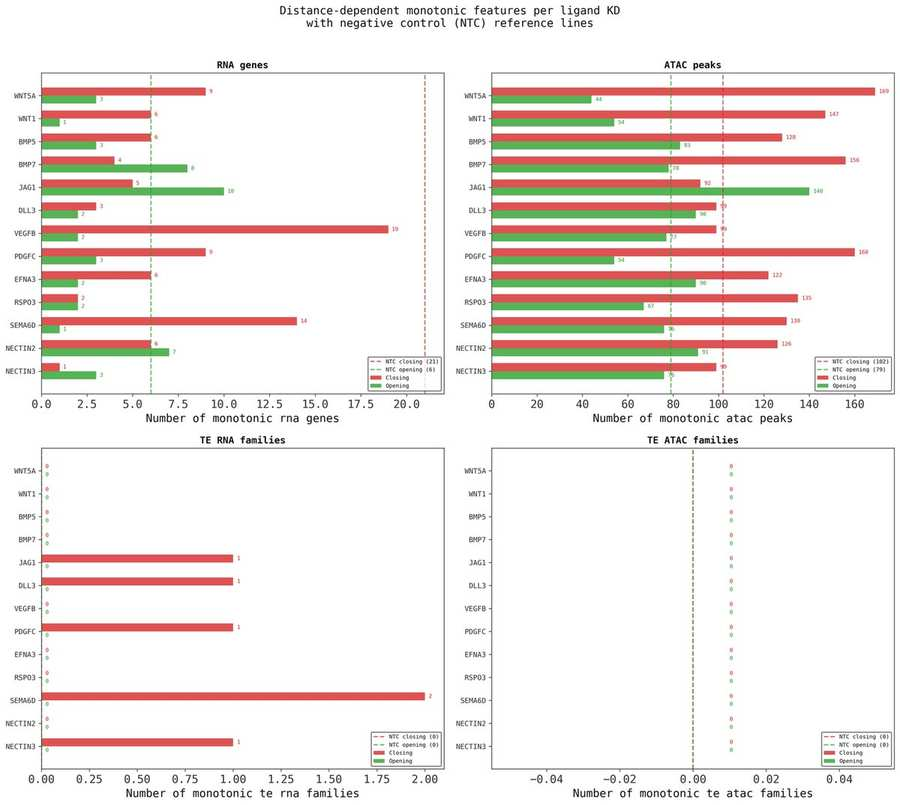

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

modalities = [
    ('rna_inc', 'rna_dec', 'RNA genes'),
    ('atac_inc', 'atac_dec', 'ATAC peaks'),
    ('te_rna_inc', 'te_rna_dec', 'TE RNA families'),
    ('te_atac_inc', 'te_atac_dec', 'TE ATAC families'),
]

for ax_idx, (inc_key, dec_key, mod_name) in enumerate(modalities):
    ax = axes[ax_idx // 2, ax_idx % 2]

    closing = [len(dist_results[t].get(inc_key, [])) for t in LIGAND_TARGETS]
    opening = [len(dist_results[t].get(dec_key, [])) for t in LIGAND_TARGETS]

    ntc_closing = len(ntc_results[inc_key])
    ntc_opening = len(ntc_results[dec_key])

    x = np.arange(len(LIGAND_TARGETS))
    w = 0.35
    ax.barh(x - w/2, closing, height=w, color='#d62728', alpha=0.8, label='Closing')
    ax.barh(x + w/2, opening, height=w, color='#2ca02c', alpha=0.8, label='Opening')

    for i, (c, o) in enumerate(zip(closing, opening)):
        max_val = max(max(closing), max(opening)) if max(closing + opening) > 0 else 1
        ax.text(c + max_val * 0.01, i - w/2, str(c), va='center', fontsize=7, color='#d62728')
        ax.text(o + max_val * 0.01, i + w/2, str(o), va='center', fontsize=7, color='#2ca02c')

    ax.axvline(ntc_closing, color='#d62728', linestyle='--', linewidth=1.5, alpha=0.7,
               label=f'NTC closing ({ntc_closing})')
    ax.axvline(ntc_opening, color='#2ca02c', linestyle='--', linewidth=1.5, alpha=0.7,
               label=f'NTC opening ({ntc_opening})')

    ax.set_yticks(x)
    ax.set_yticklabels(LIGAND_TARGETS, fontsize=9)
    ax.set_xlabel(f'Number of monotonic {mod_name.lower()}')
    ax.set_title(f'{mod_name}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=7, loc='lower right')
    ax.invert_yaxis()

plt.suptitle('Distance-dependent monotonic features per ligand KD\nwith negative control (NTC) reference lines',
            fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'distance_summary_bars_with_NTC.png'), dpi=200, bbox_inches='tight')
plt.show()


## 6. RNA closing and opening gene line plots

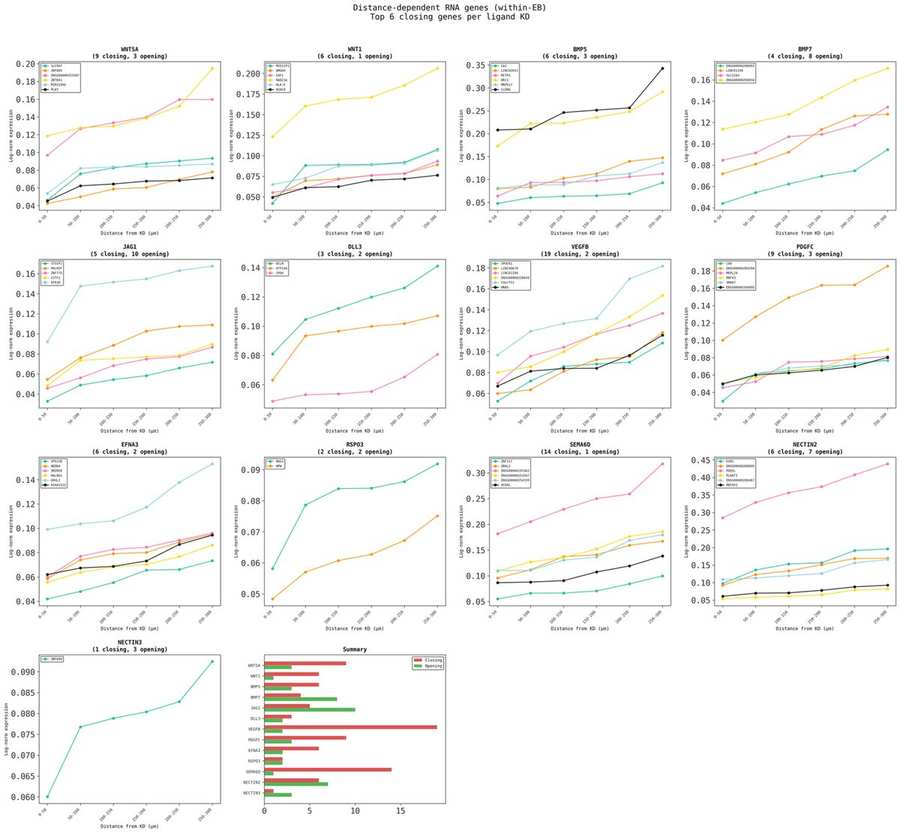

In [12]:
# RNA closing genes (top 6 per ligand KD)
fig, axes = plt.subplots(4, 4, figsize=(22, 20))

for t_idx, target in enumerate(LIGAND_TARGETS):
    ax = axes[t_idx // 4, t_idx % 4]
    entries = dist_results[target].get('rna_inc', [])[:6]
    for e in entries:
        gene = e.get('gene', e.get('te', '?'))
        ax.plot(range(len(BIN_LABELS)), e['covs'], 'o-', markersize=4, linewidth=1.3,
               label=gene, alpha=0.85)
    ax.set_xticks(range(len(BIN_LABELS)))
    ax.set_xticklabels(BIN_LABELS, fontsize=7, rotation=45, ha='right')
    ax.set_xlabel('Distance from KD (µm)', fontsize=8)
    ax.set_ylabel('Log-norm expression', fontsize=8)
    n_close = len(dist_results[target].get('rna_inc', []))
    n_open = len(dist_results[target].get('rna_dec', []))
    ax.set_title(f'{target}\n({n_close} closing, {n_open} opening)', fontsize=10, fontweight='bold')
    ax.legend(fontsize=5.5, loc='upper left')

# Summary in last panel
ax_sum = axes[3, 1]
closing = [len(dist_results[t].get('rna_inc', [])) for t in LIGAND_TARGETS]
opening = [len(dist_results[t].get('rna_dec', [])) for t in LIGAND_TARGETS]
x = np.arange(len(LIGAND_TARGETS))
ax_sum.barh(x - 0.18, closing, height=0.35, color='#d62728', alpha=0.8, label='Closing')
ax_sum.barh(x + 0.18, opening, height=0.35, color='#2ca02c', alpha=0.8, label='Opening')
ax_sum.set_yticks(x)
ax_sum.set_yticklabels(LIGAND_TARGETS, fontsize=7)
ax_sum.set_title('Summary', fontsize=10, fontweight='bold')
ax_sum.legend(fontsize=7)
ax_sum.invert_yaxis()
for idx in [14, 15]:
    axes[idx // 4, idx % 4].set_visible(False)

plt.suptitle('Distance-dependent RNA genes (within-EB)\nTop 6 closing genes per ligand KD',
            fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'distance_RNA_closing.png'), dpi=200, bbox_inches='tight')
plt.show()


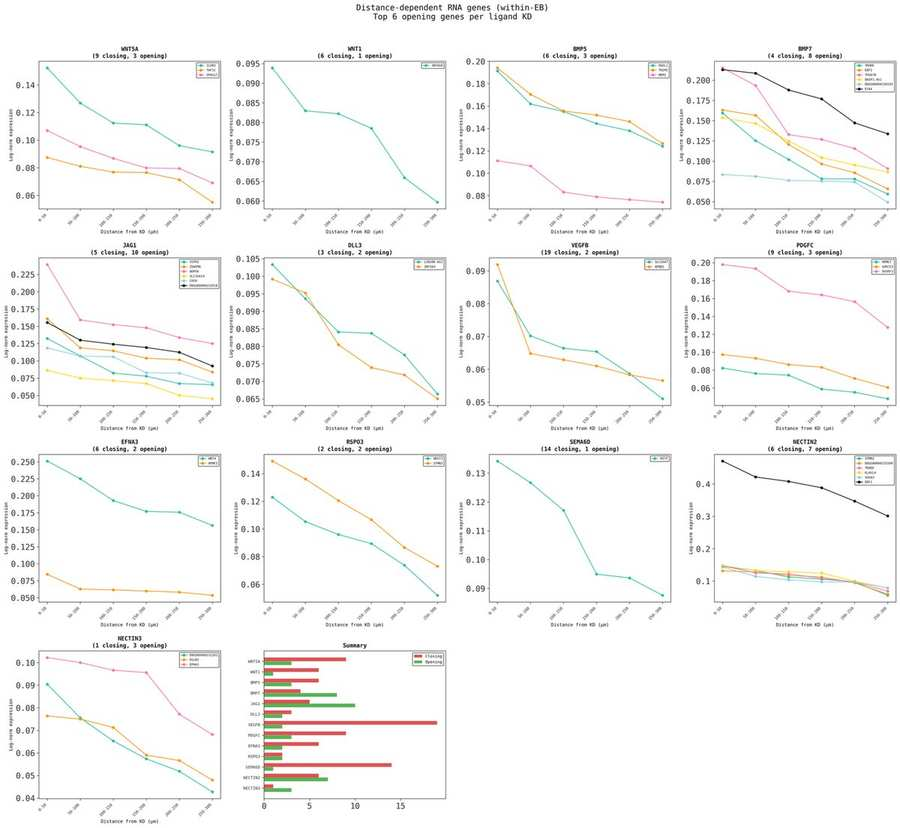

In [13]:
# RNA opening genes (top 6 per ligand KD)
fig, axes = plt.subplots(4, 4, figsize=(22, 20))

for t_idx, target in enumerate(LIGAND_TARGETS):
    ax = axes[t_idx // 4, t_idx % 4]
    entries = dist_results[target].get('rna_dec', [])[:6]
    for e in entries:
        gene = e.get('gene', e.get('te', '?'))
        ax.plot(range(len(BIN_LABELS)), e['covs'], 'o-', markersize=4, linewidth=1.3,
               label=gene, alpha=0.85)
    ax.set_xticks(range(len(BIN_LABELS)))
    ax.set_xticklabels(BIN_LABELS, fontsize=7, rotation=45, ha='right')
    ax.set_xlabel('Distance from KD (µm)', fontsize=8)
    ax.set_ylabel('Log-norm expression', fontsize=8)
    n_close = len(dist_results[target].get('rna_inc', []))
    n_open = len(dist_results[target].get('rna_dec', []))
    ax.set_title(f'{target}\n({n_close} closing, {n_open} opening)', fontsize=10, fontweight='bold')
    ax.legend(fontsize=5.5, loc='upper right')

ax_sum = axes[3, 1]
closing = [len(dist_results[t].get('rna_inc', [])) for t in LIGAND_TARGETS]
opening = [len(dist_results[t].get('rna_dec', [])) for t in LIGAND_TARGETS]
x = np.arange(len(LIGAND_TARGETS))
ax_sum.barh(x - 0.18, closing, height=0.35, color='#d62728', alpha=0.8, label='Closing')
ax_sum.barh(x + 0.18, opening, height=0.35, color='#2ca02c', alpha=0.8, label='Opening')
ax_sum.set_yticks(x)
ax_sum.set_yticklabels(LIGAND_TARGETS, fontsize=7)
ax_sum.set_title('Summary', fontsize=10, fontweight='bold')
ax_sum.legend(fontsize=7)
ax_sum.invert_yaxis()
for idx in [14, 15]:
    axes[idx // 4, idx % 4].set_visible(False)

plt.suptitle('Distance-dependent RNA genes (within-EB)\nTop 6 opening genes per ligand KD',
            fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'distance_RNA_opening.png'), dpi=200, bbox_inches='tight')
plt.show()


## 7. ATAC closing and opening peak line plots

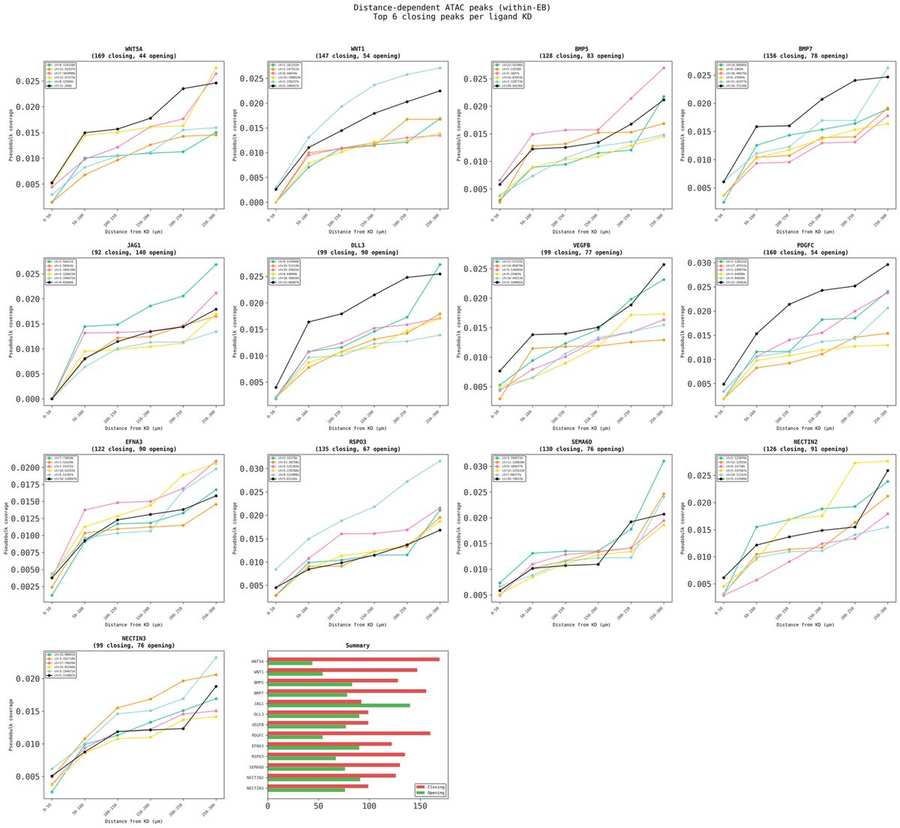

In [14]:
# ATAC closing peaks (top 6 per ligand KD)
fig, axes = plt.subplots(4, 4, figsize=(22, 20))

for t_idx, target in enumerate(LIGAND_TARGETS):
    ax = axes[t_idx // 4, t_idx % 4]
    entries = dist_results[target].get('atac_inc', [])[:6]
    for e in entries:
        label = f"{e.get('chrom','?')}:{e.get('start',0)//1000}k"
        ax.plot(range(len(BIN_LABELS)), e['covs'], 'o-', markersize=4, linewidth=1.3,
               label=label, alpha=0.85)
    ax.set_xticks(range(len(BIN_LABELS)))
    ax.set_xticklabels(BIN_LABELS, fontsize=7, rotation=45, ha='right')
    ax.set_xlabel('Distance from KD (µm)', fontsize=8)
    ax.set_ylabel('Pseudobulk coverage', fontsize=8)
    n_c = len(dist_results[target].get('atac_inc', []))
    n_o = len(dist_results[target].get('atac_dec', []))
    ax.set_title(f'{target}\n({n_c} closing, {n_o} opening)', fontsize=10, fontweight='bold')
    ax.legend(fontsize=5, loc='upper left')

ax_sum = axes[3, 1]
closing = [len(dist_results[t].get('atac_inc', [])) for t in LIGAND_TARGETS]
opening = [len(dist_results[t].get('atac_dec', [])) for t in LIGAND_TARGETS]
x = np.arange(len(LIGAND_TARGETS))
ax_sum.barh(x - 0.18, closing, height=0.35, color='#d62728', alpha=0.8, label='Closing')
ax_sum.barh(x + 0.18, opening, height=0.35, color='#2ca02c', alpha=0.8, label='Opening')
ax_sum.set_yticks(x)
ax_sum.set_yticklabels(LIGAND_TARGETS, fontsize=7)
ax_sum.set_title('Summary', fontsize=10, fontweight='bold')
ax_sum.legend(fontsize=7)
ax_sum.invert_yaxis()
for idx in [14, 15]:
    axes[idx // 4, idx % 4].set_visible(False)

plt.suptitle('Distance-dependent ATAC peaks (within-EB)\nTop 6 closing peaks per ligand KD',
            fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'distance_ATAC_closing.png'), dpi=200, bbox_inches='tight')
plt.show()


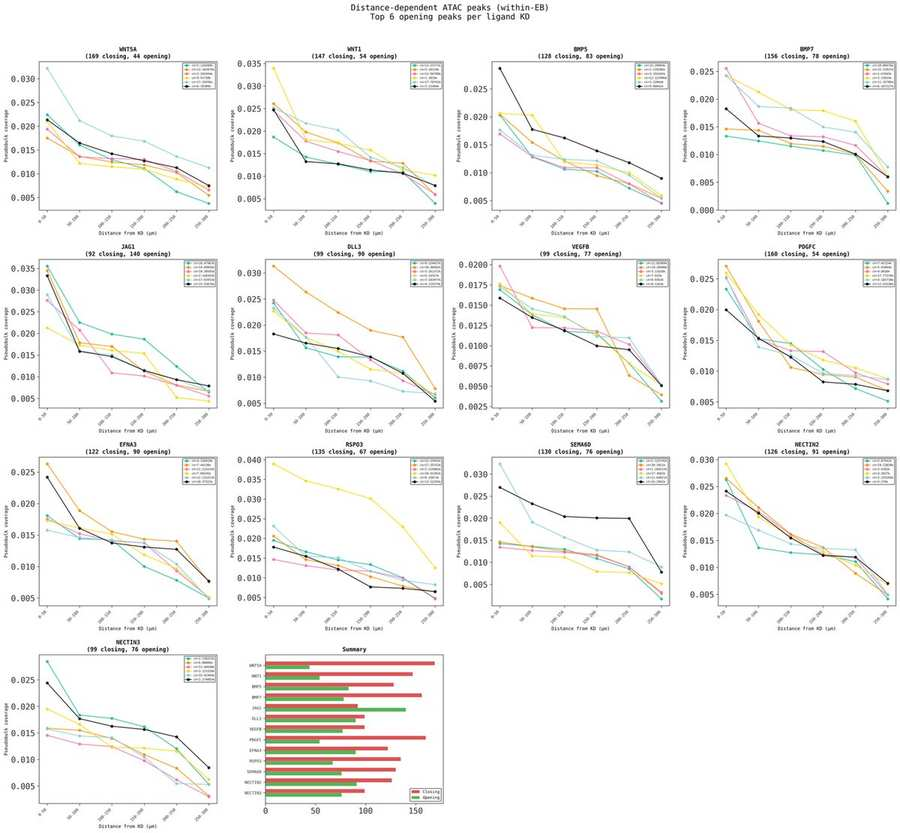

In [15]:
# ATAC opening peaks (top 6 per ligand KD)
fig, axes = plt.subplots(4, 4, figsize=(22, 20))

for t_idx, target in enumerate(LIGAND_TARGETS):
    ax = axes[t_idx // 4, t_idx % 4]
    entries = dist_results[target].get('atac_dec', [])[:6]
    for e in entries:
        label = f"{e.get('chrom','?')}:{e.get('start',0)//1000}k"
        ax.plot(range(len(BIN_LABELS)), e['covs'], 'o-', markersize=4, linewidth=1.3,
               label=label, alpha=0.85)
    ax.set_xticks(range(len(BIN_LABELS)))
    ax.set_xticklabels(BIN_LABELS, fontsize=7, rotation=45, ha='right')
    ax.set_xlabel('Distance from KD (µm)', fontsize=8)
    ax.set_ylabel('Pseudobulk coverage', fontsize=8)
    n_c = len(dist_results[target].get('atac_inc', []))
    n_o = len(dist_results[target].get('atac_dec', []))
    ax.set_title(f'{target}\n({n_c} closing, {n_o} opening)', fontsize=10, fontweight='bold')
    ax.legend(fontsize=5, loc='upper right')

ax_sum = axes[3, 1]
closing = [len(dist_results[t].get('atac_inc', [])) for t in LIGAND_TARGETS]
opening = [len(dist_results[t].get('atac_dec', [])) for t in LIGAND_TARGETS]
x = np.arange(len(LIGAND_TARGETS))
ax_sum.barh(x - 0.18, closing, height=0.35, color='#d62728', alpha=0.8, label='Closing')
ax_sum.barh(x + 0.18, opening, height=0.35, color='#2ca02c', alpha=0.8, label='Opening')
ax_sum.set_yticks(x)
ax_sum.set_yticklabels(LIGAND_TARGETS, fontsize=7)
ax_sum.set_title('Summary', fontsize=10, fontweight='bold')
ax_sum.legend(fontsize=7)
ax_sum.invert_yaxis()
for idx in [14, 15]:
    axes[idx // 4, idx % 4].set_visible(False)

plt.suptitle('Distance-dependent ATAC peaks (within-EB)\nTop 6 opening peaks per ligand KD',
            fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'distance_ATAC_opening.png'), dpi=200, bbox_inches='tight')
plt.show()


## 8. TE family line plots

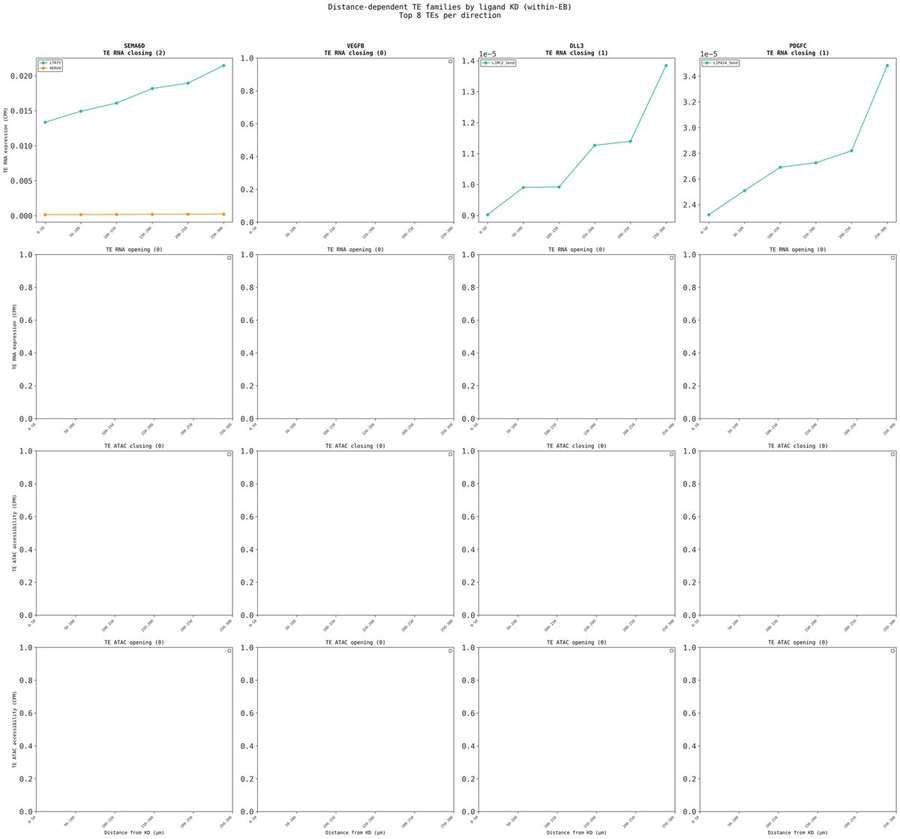

In [16]:
# TE line plots for top 4 targets
top_targets = ['SEMA6D', 'VEGFB', 'DLL3', 'PDGFC']

fig, axes = plt.subplots(4, 4, figsize=(24, 22))

for col_idx, target in enumerate(top_targets):
    for row_idx, (key, title_suffix, ylabel) in enumerate([
        ('te_rna_inc', 'TE RNA closing', 'TE RNA expression (CPM)'),
        ('te_rna_dec', 'TE RNA opening', 'TE RNA expression (CPM)'),
        ('te_atac_inc', 'TE ATAC closing', 'TE ATAC accessibility (CPM)'),
        ('te_atac_dec', 'TE ATAC opening', 'TE ATAC accessibility (CPM)'),
    ]):
        ax = axes[row_idx, col_idx]
        entries = dist_results[target].get(key, [])[:8]
        for e in entries:
            te_name = e.get('te', e.get('gene', '?'))
            ax.plot(range(len(BIN_LABELS)), e['covs'], 'o-', markersize=5, linewidth=1.5,
                   label=te_name, alpha=0.85)
        ax.set_xticks(range(len(BIN_LABELS)))
        ax.set_xticklabels(BIN_LABELS, fontsize=7, rotation=45, ha='right')
        n = len(dist_results[target].get(key, []))
        if row_idx == 0:
            ax.set_title(f'{target}\n{title_suffix} ({n})', fontsize=11, fontweight='bold')
        else:
            ax.set_title(f'{title_suffix} ({n})', fontsize=10)
        ax.legend(fontsize=7, loc='best')
        if col_idx == 0:
            ax.set_ylabel(ylabel, fontsize=9)
        if row_idx == 3:
            ax.set_xlabel('Distance from KD (µm)', fontsize=9)

plt.suptitle('Distance-dependent TE families by ligand KD (within-EB)\nTop 8 TEs per direction',
            fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'distance_TE_lineplots.png'), dpi=200, bbox_inches='tight')
plt.show()


## 9. Recurrent TE heatmap across ligand KDs

In [17]:
# Count how many targets each TE family appears in, per direction
from collections import Counter

directions = {
    'TE RNA closing': 'te_rna_inc',
    'TE RNA opening': 'te_rna_dec',
    'TE ATAC closing': 'te_atac_inc',
    'TE ATAC opening': 'te_atac_dec',
}

for dir_name, key in directions.items():
    te_counter = Counter()
    te_by_target = defaultdict(set)
    for target in LIGAND_TARGETS:
        for e in dist_results[target].get(key, []):
            te_name = e.get('te', e.get('gene', '?'))
            te_counter[te_name] += 1
            te_by_target[te_name].add(target)

    # Show TEs appearing in 3+ targets
    recurrent = {te: count for te, count in te_counter.items() if count >= 3}
    if recurrent:
        print(f"\n{dir_name} — TEs in ≥3 targets:")
        for te, count in sorted(recurrent.items(), key=lambda x: -x[1]):
            print(f"  {te}: {count}/13 targets ({', '.join(sorted(te_by_target[te]))})")

# Build heatmap for TE RNA closing (the most striking result)
print("\n\nBuilding recurrent TE heatmap...")
heatmap_data = {}
for dir_name, key in directions.items():
    te_target_matrix = defaultdict(lambda: defaultdict(int))
    for target in LIGAND_TARGETS:
        for e in dist_results[target].get(key, []):
            te_name = e.get('te', e.get('gene', '?'))
            te_target_matrix[te_name][target] = 1

    # Filter to TEs in 3+ targets
    for te, targets_dict in te_target_matrix.items():
        if sum(targets_dict.values()) >= 3:
            heatmap_data[(dir_name, te)] = targets_dict

if heatmap_data:
    # Create heatmap
    te_labels = sorted(set(te for _, te in heatmap_data.keys()))
    dir_labels = list(directions.keys())

    # Organize by direction
    fig, ax = plt.subplots(figsize=(16, max(8, len(te_labels) * 0.4)))

    matrix = np.zeros((len(te_labels), len(LIGAND_TARGETS)))
    row_labels = []
    row_dirs = []

    sorted_entries = []
    for dir_name in dir_labels:
        dir_tes = [(te, sum(heatmap_data[(dir_name, te)].values())) 
                   for _, te in heatmap_data.keys() if _ == dir_name]
        dir_tes.sort(key=lambda x: -x[1])
        for te, count in dir_tes:
            sorted_entries.append((dir_name, te))

    matrix = np.zeros((len(sorted_entries), len(LIGAND_TARGETS)))
    for i, (dir_name, te) in enumerate(sorted_entries):
        for j, target in enumerate(LIGAND_TARGETS):
            matrix[i, j] = heatmap_data[(dir_name, te)].get(target, 0)

    row_labels = [f"{te} ({d.split()[1]} {d.split()[2]})" for d, te in sorted_entries]

    im = ax.imshow(matrix, cmap='YlOrRd', aspect='auto', interpolation='nearest')
    ax.set_xticks(range(len(LIGAND_TARGETS)))
    ax.set_xticklabels(LIGAND_TARGETS, rotation=45, ha='right', fontsize=9)
    ax.set_yticks(range(len(row_labels)))
    ax.set_yticklabels(row_labels, fontsize=8)
    ax.set_title('Recurrent TE families across ligand KDs (≥3 targets)', fontsize=13, fontweight='bold')
    plt.colorbar(im, ax=ax, label='Present (1) / Absent (0)', shrink=0.5)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'distance_TE_recurrent_heatmap.png'), dpi=200, bbox_inches='tight')
    plt.show()
else:
    print("No recurrent TEs found in ≥3 targets")




Building recurrent TE heatmap...
No recurrent TEs found in ≥3 targets


## 10. NTC distance line plots

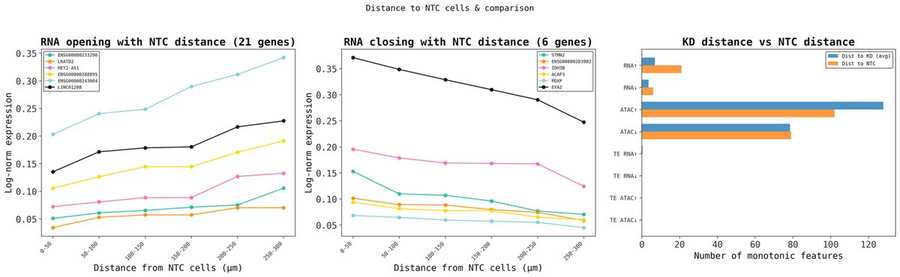


All ligand distance figures saved to: output


In [18]:
# NTC distance plots
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# RNA opening
ax = axes[0]
for e in ntc_results['rna_inc'][:6]:
    ax.plot(range(6), e['covs'], 'o-', markersize=5, linewidth=1.5, label=e.get('gene','?'), alpha=0.85)
ax.set_xticks(range(6))
ax.set_xticklabels(BIN_LABELS, fontsize=9, rotation=45, ha='right')
ax.set_xlabel('Distance from NTC cells (µm)')
ax.set_ylabel('Log-norm expression')
ax.set_title(f'RNA opening with NTC distance ({len(ntc_results["rna_inc"])} genes)', fontweight='bold')
ax.legend(fontsize=7)

# RNA closing
ax = axes[1]
for e in ntc_results['rna_dec'][:6]:
    ax.plot(range(6), e['covs'], 'o-', markersize=5, linewidth=1.5, label=e.get('gene','?'), alpha=0.85)
ax.set_xticks(range(6))
ax.set_xticklabels(BIN_LABELS, fontsize=9, rotation=45, ha='right')
ax.set_xlabel('Distance from NTC cells (µm)')
ax.set_ylabel('Log-norm expression')
ax.set_title(f'RNA closing with NTC distance ({len(ntc_results["rna_dec"])} genes)', fontweight='bold')
ax.legend(fontsize=7)

# Summary comparison
ax = axes[2]
categories = ['RNA↑', 'RNA↓', 'ATAC↑', 'ATAC↓', 'TE RNA↑', 'TE RNA↓', 'TE ATAC↑', 'TE ATAC↓']
keys = ['rna_inc', 'rna_dec', 'atac_inc', 'atac_dec', 'te_rna_inc', 'te_rna_dec', 'te_atac_inc', 'te_atac_dec']
kd_avg = [np.mean([len(dist_results[t].get(k, [])) for t in LIGAND_TARGETS]) for k in keys]
ntc_vals = [len(ntc_results[k]) for k in keys]
x = np.arange(len(categories))
w = 0.35
ax.barh(x - w/2, kd_avg, height=w, color='#1f77b4', alpha=0.8, label='Dist to KD (avg)')
ax.barh(x + w/2, ntc_vals, height=w, color='#ff7f0e', alpha=0.8, label='Dist to NTC')
ax.set_yticks(x)
ax.set_yticklabels(categories, fontsize=9)
ax.set_xlabel('Number of monotonic features')
ax.set_title('KD distance vs NTC distance', fontweight='bold')
ax.legend(fontsize=8)
ax.invert_yaxis()

plt.suptitle('Distance to NTC cells & comparison', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'distance_to_NTC_comparison.png'), dpi=200, bbox_inches='tight')
plt.show()

print("\nAll ligand distance figures saved to:", OUTPUT_DIR)
